# 06 Generation Integrity and Operational Audit

This notebook audits the frozen benchmark-generation run before any
answer-quality evaluation is performed.

The notebook has four purposes:

1. Verify the exact public and private file fingerprints.
2. Confirm that all 140 planned responses are present exactly once.
3. Summarise completion status, token usage, latency, retries, response
   length, and cost boundaries.
4. Produce text-free operational visualisations by experimental
   condition.

## Privacy and evaluation boundary

- Generated response text is read only to calculate length measures.
- Generated response text is never displayed or exported.
- Benchmark question text is not loaded.
- Ground truth is not accessed.
- No correctness, relevance, or answer-quality score is calculated.
- Only aggregate operational evidence is shown.

This separation keeps generation integrity independent from the later
evaluation and baseline-comparison phase.

## 1. Environment and project root

The analysis uses the versions frozen in `requirements-lock.txt`.
The project-root logic supports execution either from the repository
root or from the `notebooks` directory.

In [1]:
from __future__ import annotations

import hashlib
import json
from decimal import Decimal
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


current_directory = Path.cwd().resolve()

if (current_directory / "configs").is_dir():
    ROOT = current_directory
elif (current_directory.parent / "configs").is_dir():
    ROOT = current_directory.parent
else:
    raise RuntimeError(
        "The thesis project root could not be located."
    )

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
)

print("Generation audit environment:")
print("  Project root:", ROOT)
print("  pandas:", pd.__version__)
print("  matplotlib:", matplotlib.__version__)
print("  seaborn:", sns.__version__)
print("  Ground truth accessed: False")

Generation audit environment:
  Project root: /home/zaki/coding_F/GismaProjects/Thesis
  pandas: 3.0.6
  matplotlib: 3.11.2
  seaborn: 0.13.2
  Ground truth accessed: False


## 2. Frozen lineage and file fingerprints

The expected fingerprints were recorded before this notebook was
created. Verifying them here prevents the analysis from silently using
modified configuration, implementation, or response files.

In [2]:
EXPECTED_CONFIGURATION_ID = (
    "benchmark-generation-evaluation-v1"
)

EXPECTED_CONDITION_IDS = (
    "P0",
    "P1",
    "P2",
    "P3",
    "M1",
    "M2",
    "M3",
)

EXPECTED_MODELS = {
    "P0": "gpt-4-0613",
    "P1": "gpt-4-0613",
    "P2": "gpt-4-0613",
    "P3": "gpt-4-0613",
    "M1": "gpt-4.1-2025-04-14",
    "M2": "gpt-5-2025-08-07",
    "M3": "gpt-6-astra",
}

RELATIVE_PATHS = {
    "configuration": (
        "configs/generation-evaluation-config.json"
    ),
    "pricing": (
        "configs/generation-pricing-snapshot.json"
    ),
    "authorization": (
        "configs/generation-cost-authorization.json"
    ),
    "enablement": (
        "configs/generation-execution-enablement.json"
    ),
    "preflight": (
        "results/metrics/"
        "generation-model-preflight.json"
    ),
    "implementation": (
        "src/geotech_rag/generation_execution.py"
    ),
    "checkpoint": (
        "data/raw/evaluation/generation/v1/"
        "responses-checkpoint.jsonl"
    ),
    "checkpoint_metadata": (
        "data/raw/evaluation/generation/v1/"
        "responses-checkpoint-metadata.json"
    ),
    "responses": (
        "data/raw/evaluation/generation/v1/"
        "responses.jsonl"
    ),
}

EXPECTED_SHA256 = {
    "configuration": (
        "55e1e709a5bd31486656668301d8e44c"
        "470673f14d745d7cfaae4a6c154d2667"
    ),
    "pricing": (
        "cb44165530f8eac7f5fd11c00c400c34"
        "0a4566095ed57a8f54e83371650056e9"
    ),
    "authorization": (
        "699b56dccf17952f436ac0f3d419cb6a"
        "1b67abadf9b7e64a8676de35504d2c80"
    ),
    "enablement": (
        "04901dc6a2381a326f2a9f949199d7d1"
        "ac68469d2304f6fdf72de30bcd684797"
    ),
    "preflight": (
        "469c3bb5ad15fe6b1bd8fac96e43c057"
        "a1a12781369701dc6e0344d4a441b967"
    ),
    "implementation": (
        "79e6967e5513b29d528ac972ece358584"
        "2362bcf51b45461d65f5071521b8acf"
    ),
    "checkpoint": (
        "b5b6d661ef17d7b931561941ba3a488fe"
        "93e4344ecb11944a6e1cf93aa6d9a76"
    ),
    "checkpoint_metadata": (
        "2e521b38e6fb81973d4d37489198acc7e"
        "f9743064d8caeda71b7e6950f12e9da"
    ),
    "responses": (
        "b5b6d661ef17d7b931561941ba3a488fe"
        "93e4344ecb11944a6e1cf93aa6d9a76"
    ),
}

PATHS = {
    name: ROOT / relative_path
    for name, relative_path in RELATIVE_PATHS.items()
}

In [3]:
def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for block in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


fingerprint_rows = []

for name, path in PATHS.items():
    if not path.is_file():
        raise RuntimeError(
            f"Required audit input is absent: {path}"
        )

    observed_sha256 = file_sha256(path)
    expected_sha256 = EXPECTED_SHA256[name]

    if observed_sha256 != expected_sha256:
        raise RuntimeError(
            (
                f"Fingerprint mismatch for {name}: "
                f"{observed_sha256}"
            )
        )

    fingerprint_rows.append(
        {
            "artifact": name,
            "relative_path": RELATIVE_PATHS[name],
            "sha256": observed_sha256,
            "verified": True,
        }
    )

if (
    PATHS["checkpoint"].read_bytes()
    != PATHS["responses"].read_bytes()
):
    raise RuntimeError(
        (
            "The checkpoint and final response "
            "files are not identical."
        )
    )

fingerprint_table = pd.DataFrame(
    fingerprint_rows
)

display(fingerprint_table)

print("Frozen lineage verification: PASSED")
print("Checkpoint equals final response file: True")
print("Private response text displayed: False")

,artifact,relative_path,sha256,verified
0,configuration,configs/generation-evaluation-config.json,55e1e709a5bd31486656668301d8e44c470673f14d745d...,True
1,pricing,configs/generation-pricing-snapshot.json,cb44165530f8eac7f5fd11c00c400c340a4566095ed57a...,True
2,authorization,configs/generation-cost-authorization.json,699b56dccf17952f436ac0f3d419cb6a1b67abadf9b7e6...,True
3,enablement,configs/generation-execution-enablement.json,04901dc6a2381a326f2a9f949199d7d1ac68469d2304f6...,True
4,preflight,results/metrics/generation-model-preflight.json,469c3bb5ad15fe6b1bd8fac96e43c057a1a12781369701...,True
5,implementation,src/geotech_rag/generation_execution.py,79e6967e5513b29d528ac972ece3585842362bcf51b454...,True
6,checkpoint,data/raw/evaluation/generation/v1/responses-ch...,b5b6d661ef17d7b931561941ba3a488fe93e4344ecb119...,True
7,checkpoint_metadata,data/raw/evaluation/generation/v1/responses-ch...,2e521b38e6fb81973d4d37489198acc7ef9743064d8cae...,True
8,responses,data/raw/evaluation/generation/v1/responses.jsonl,b5b6d661ef17d7b931561941ba3a488fe93e4344ecb119...,True


Frozen lineage verification: PASSED
Checkpoint equals final response file: True
Private response text displayed: False


## 3. Load and protect the private response records

The response contract is checked before constructing the analysis
table. The `response_text` field is converted into character and word
counts, then removed before any table is displayed.

In [4]:
REQUIRED_RESPONSE_FIELDS = frozenset(
    {
        "blinded_response_id",
        "completion_status",
        "condition_id",
        "configuration_id",
        "input_token_count",
        "output_token_count",
        "prompt_sha256",
        "question_id",
        "reasoning_effort",
        "record_schema_version",
        "request_started_at_utc",
        "requested_model_id",
        "response_id",
        "response_received_at_utc",
        "response_text",
        "retrieved_evidence_sha256",
        "retry_count",
        "returned_model_id",
        "system_fingerprint",
        "temperature",
        "top_p",
        "total_token_count",
    }
)

response_records = []

with PATHS["responses"].open(
    "r",
    encoding="utf-8",
) as file:
    for line_number, line in enumerate(
        file,
        start=1,
    ):
        if not line.strip():
            raise RuntimeError(
                (
                    "Blank response record at line "
                    f"{line_number}."
                )
            )

        record = json.loads(line)

        if not isinstance(record, dict):
            raise RuntimeError(
                (
                    "Response record is not an object "
                    f"at line {line_number}."
                )
            )

        observed_fields = frozenset(record)

        if observed_fields != REQUIRED_RESPONSE_FIELDS:
            missing = sorted(
                REQUIRED_RESPONSE_FIELDS
                - observed_fields
            )
            extra = sorted(
                observed_fields
                - REQUIRED_RESPONSE_FIELDS
            )

            raise RuntimeError(
                (
                    "Unexpected response contract at "
                    f"line {line_number}. "
                    f"Missing={missing}; extra={extra}"
                )
            )

        response_records.append(record)

if len(response_records) != 140:
    raise RuntimeError(
        (
            "Expected 140 response records, found "
            f"{len(response_records)}."
        )
    )

with PATHS["checkpoint_metadata"].open(
    "r",
    encoding="utf-8",
) as file:
    checkpoint_metadata = json.load(file)

with PATHS["authorization"].open(
    "r",
    encoding="utf-8",
) as file:
    authorization = json.load(file)

safe_records = []

for record in response_records:
    response_text = record["response_text"]

    if not isinstance(response_text, str):
        raise RuntimeError(
            (
                "A response_text value is not a "
                "string."
            )
        )

    safe_record = {
        key: value
        for key, value in record.items()
        if key != "response_text"
    }

    safe_record["response_character_count"] = (
        len(response_text)
    )
    safe_record["response_word_count"] = len(
        response_text.split()
    )

    safe_records.append(safe_record)

responses = pd.DataFrame(safe_records)

del response_records
del safe_records
del response_text
del safe_record
del record

if "response_text" in responses.columns:
    raise RuntimeError(
        "Private response text remained in the table."
    )

for column in (
    "request_started_at_utc",
    "response_received_at_utc",
):
    responses[column] = pd.to_datetime(
        responses[column],
        utc=True,
        errors="raise",
    )

responses["latency_seconds"] = (
    responses["response_received_at_utc"]
    - responses["request_started_at_utc"]
).dt.total_seconds()

if responses["latency_seconds"].lt(0).any():
    raise RuntimeError(
        "A negative request latency was found."
    )

responses["condition_id"] = pd.Categorical(
    responses["condition_id"],
    categories=EXPECTED_CONDITION_IDS,
    ordered=True,
)

print("Private response loading:")
print("  Records loaded:", len(responses))
print("  Safe analysis columns:", len(responses.columns))
print("  response_text retained: False")
print("  response_text displayed: False")
print("Private response loading: PASSED")

Private response loading:
  Records loaded: 140
  Safe analysis columns: 24
  response_text retained: False
  response_text displayed: False
Private response loading: PASSED


## 4. Experimental-matrix validation

The frozen design requires 20 questions under each of seven conditions.
Each question-condition pair must occur exactly once. Requested and
returned model identities must also match the frozen model mapping.

In [5]:
observed_conditions = tuple(
    condition
    for condition in EXPECTED_CONDITION_IDS
    if condition
    in set(
        responses["condition_id"]
        .dropna()
        .astype(str)
    )
)

if observed_conditions != EXPECTED_CONDITION_IDS:
    raise RuntimeError(
        (
            "Observed conditions do not match "
            "the frozen condition order."
        )
    )

unique_question_count = int(
    responses["question_id"].nunique()
)

if unique_question_count != 20:
    raise RuntimeError(
        (
            "Expected 20 unique questions, found "
            f"{unique_question_count}."
        )
    )

response_matrix = (
    responses.groupby(
        [
            "question_id",
            "condition_id",
        ],
        observed=True,
    )
    .size()
    .unstack(
        fill_value=0,
    )
    .reindex(
        columns=EXPECTED_CONDITION_IDS,
        fill_value=0,
    )
)

if response_matrix.shape != (20, 7):
    raise RuntimeError(
        (
            "Unexpected response-matrix shape: "
            f"{response_matrix.shape}"
        )
    )

if not response_matrix.eq(1).all().all():
    raise RuntimeError(
        (
            "At least one question-condition pair "
            "is missing or duplicated."
        )
    )

if not responses["blinded_response_id"].is_unique:
    raise RuntimeError(
        "Duplicate blinded response identifiers found."
    )

if not responses["response_id"].is_unique:
    raise RuntimeError(
        "Duplicate API response identifiers found."
    )

expected_requested_models = (
    responses["condition_id"]
    .astype("object")
    .map(EXPECTED_MODELS)
)

if not responses["requested_model_id"].eq(
    expected_requested_models
).all():
    raise RuntimeError(
        (
            "A requested model does not match "
            "the frozen condition mapping."
        )
    )

model_identity_matches = responses[
    "requested_model_id"
].eq(
    responses["returned_model_id"]
)

if not model_identity_matches.all():
    raise RuntimeError(
        (
            "A returned model differs from the "
            "requested model."
        )
    )

total_retry_count = int(
    responses["retry_count"].sum()
)

if total_retry_count != 0:
    raise RuntimeError(
        (
            "The recorded run was expected to have "
            "zero retries."
        )
    )

completion_status_table = (
    responses["completion_status"]
    .value_counts(
        dropna=False,
    )
    .rename_axis("completion_status")
    .reset_index(name="response_count")
)

matrix_summary = pd.DataFrame(
    {
        "metric": [
            "Response records",
            "Unique questions",
            "Conditions",
            "Question-condition pairs",
            "Unique blinded response IDs",
            "Unique API response IDs",
            "Requested-returned model matches",
            "Total retries",
        ],
        "value": [
            len(responses),
            unique_question_count,
            len(EXPECTED_CONDITION_IDS),
            int(response_matrix.size),
            int(
                responses[
                    "blinded_response_id"
                ].nunique()
            ),
            int(
                responses[
                    "response_id"
                ].nunique()
            ),
            int(model_identity_matches.sum()),
            total_retry_count,
        ],
    }
)

display(matrix_summary)
display(completion_status_table)

print("Experimental matrix validation: PASSED")

,metric,value
0,Response records,140
1,Unique questions,20
2,Conditions,7
3,Question-condition pairs,140
4,Unique blinded response IDs,140
5,Unique API response IDs,140
6,Requested-returned model matches,140
7,Total retries,0


,completion_status,response_count
0,completed,131
1,empty,9


Experimental matrix validation: PASSED


### 4.1 Empty-response diagnostic

The matrix contains all 140 planned API responses, but nine M2
responses contain no visible answer text. Each of these records used
exactly 2,000 reported output tokens, which is the frozen logical
output limit.

OpenAI explains that Chat Completions output-token usage includes all
generated tokens, not only text visible in the response. The
`max_completion_tokens` parameter limits visible and non-visible
generation:

- [OpenAI: Understand output token counts](https://developers.openai.com/api/docs/guides/token-counting#understand-output-token-counts)
- [OpenAI: Allocating space for reasoning](https://developers.openai.com/api/docs/guides/reasoning#allocating-space-for-reasoning)

The observed pattern is therefore consistent with the 2,000-token
completion limit being exhausted before visible text was produced.
This is not presented as direct proof of the internal token breakdown
because reasoning-token details and the finish reason were not retained
in the frozen response contract.

The empty responses remain part of the primary experiment.
Regenerating only these records with a larger limit would change M2
after observing its results and could bias the model comparison.

In [6]:
completion_status_by_condition = (
    pd.crosstab(
        responses["condition_id"],
        responses["completion_status"],
        dropna=False,
    )
    .reindex(
        index=EXPECTED_CONDITION_IDS,
        fill_value=0,
    )
    .reindex(
        columns=[
            "completed",
            "empty",
        ],
        fill_value=0,
    )
)

empty_responses = responses.loc[
    responses["completion_status"].eq("empty")
].copy()

if len(empty_responses) != 9:
    raise RuntimeError(
        (
            "Expected nine empty responses, found "
            f"{len(empty_responses)}."
        )
    )

empty_condition_ids = set(
    empty_responses[
        "condition_id"
    ].astype(str)
)

if empty_condition_ids != {"M2"}:
    raise RuntimeError(
        (
            "An empty response occurred outside "
            "the frozen M2 condition."
        )
    )

if not empty_responses[
    "output_token_count"
].eq(2000).all():
    raise RuntimeError(
        (
            "An empty M2 response did not reach "
            "the 2,000-token output limit."
        )
    )

if not empty_responses[
    "response_character_count"
].eq(0).all():
    raise RuntimeError(
        (
            "An empty response contains visible "
            "characters."
        )
    )

if not empty_responses[
    "reasoning_effort"
].eq("low").all():
    raise RuntimeError(
        (
            "An empty M2 response has an "
            "unexpected reasoning effort."
        )
    )

if not empty_responses[
    "retry_count"
].eq(0).all():
    raise RuntimeError(
        (
            "An empty response was unexpectedly "
            "retried."
        )
    )

empty_response_summary = (
    empty_responses.groupby(
        [
            "condition_id",
            "requested_model_id",
            "reasoning_effort",
        ],
        observed=True,
    )
    .agg(
        empty_response_count=(
            "completion_status",
            "size",
        ),
        total_output_tokens=(
            "output_token_count",
            "sum",
        ),
        minimum_output_tokens=(
            "output_token_count",
            "min",
        ),
        median_output_tokens=(
            "output_token_count",
            "median",
        ),
        maximum_output_tokens=(
            "output_token_count",
            "max",
        ),
        visible_characters=(
            "response_character_count",
            "sum",
        ),
        retries=(
            "retry_count",
            "sum",
        ),
    )
    .reset_index()
)

display(
    completion_status_by_condition
    .rename_axis("condition_id")
    .reset_index()
)
display(empty_response_summary)

print("Empty-response diagnostic:")
print("  Empty responses: 9")
print("  Empty-response condition: M2")
print("  Frozen output-token limit: 2000")
print("  Visible characters returned: 0")
print("  Selective regeneration performed: False")
print(
    "  Interpretation: consistent with "
    "completion-limit exhaustion"
)
print("Empty-response diagnostic: PASSED")

completion_status,condition_id,completed,empty
0,P0,20,0
1,P1,20,0
2,P2,20,0
3,P3,20,0
4,M1,20,0
5,M2,11,9
6,M3,20,0


,condition_id,requested_model_id,reasoning_effort,empty_response_count,total_output_tokens,minimum_output_tokens,median_output_tokens,maximum_output_tokens,visible_characters,retries
0,M2,gpt-5-2025-08-07,low,9,18000,2000,2000.0,2000,0,0


Empty-response diagnostic:
  Empty responses: 9
  Empty-response condition: M2
  Frozen output-token limit: 2000
  Visible characters returned: 0
  Selective regeneration performed: False
  Interpretation: consistent with completion-limit exhaustion
Empty-response diagnostic: PASSED


## 5. Operational summary by condition

These summaries describe generation behaviour only. Longer answers,
higher token use, or lower latency do not imply better answer quality.

In [7]:
condition_summary = (
    responses.groupby(
        "condition_id",
        observed=True,
    )
    .agg(
        response_count=(
            "blinded_response_id",
            "size",
        ),
        input_tokens=(
            "input_token_count",
            "sum",
        ),
        output_tokens=(
            "output_token_count",
            "sum",
        ),
        total_tokens=(
            "total_token_count",
            "sum",
        ),
        mean_total_tokens=(
            "total_token_count",
            "mean",
        ),
        median_output_tokens=(
            "output_token_count",
            "median",
        ),
        mean_response_characters=(
            "response_character_count",
            "mean",
        ),
        median_response_characters=(
            "response_character_count",
            "median",
        ),
        median_latency_seconds=(
            "latency_seconds",
            "median",
        ),
        total_retries=(
            "retry_count",
            "sum",
        ),
    )
    .reset_index()
)

condition_summary.insert(
    1,
    "requested_model_id",
    condition_summary["condition_id"]
    .astype("object")
    .map(EXPECTED_MODELS),
)

numeric_columns_to_round = (
    "mean_total_tokens",
    "median_output_tokens",
    "mean_response_characters",
    "median_response_characters",
    "median_latency_seconds",
)

condition_summary[
    list(numeric_columns_to_round)
] = condition_summary[
    list(numeric_columns_to_round)
].round(2)

known_usage_cost = Decimal(
    checkpoint_metadata[
        "known_usage_cost_usd"
    ]
)
conservative_committed_cost = Decimal(
    checkpoint_metadata[
        "conservative_committed_cost_usd"
    ]
)
authorized_hard_cap = Decimal(
    str(
        authorization[
            "authorized_maximum_cost_usd"
        ]
    )
)

if not (
    known_usage_cost
    <= conservative_committed_cost
    <= authorized_hard_cap
):
    raise RuntimeError(
        "The recorded cost boundaries are inconsistent."
    )

run_summary = pd.DataFrame(
    {
        "metric": [
            "Configuration ID",
            "Completed responses",
            "Known usage cost (USD)",
            "Conservative committed cost (USD)",
            "Authorized hard cap (USD)",
            "Known-cost share of hard cap (%)",
            "Ground truth accessed",
            "Response text exported",
        ],
        "value": [
            checkpoint_metadata[
                "configuration_id"
            ],
            checkpoint_metadata[
                "completed_response_count"
            ],
            f"{known_usage_cost:.6f}",
            f"{conservative_committed_cost:.6f}",
            f"{authorized_hard_cap:.6f}",
            (
                f"{(
                    known_usage_cost
                    / authorized_hard_cap
                    * Decimal('100')
                ):.2f}"
            ),
            False,
            False,
        ],
    }
)

display(run_summary)
display(condition_summary)

print("Operational summary creation: PASSED")

,metric,value
0,Configuration ID,benchmark-generation-evaluation-v1
1,Completed responses,140
2,Known usage cost (USD),9.252072
3,Conservative committed cost (USD),17.952680
4,Authorized hard cap (USD),25.000000
5,Known-cost share of hard cap (%),37.01
6,Ground truth accessed,False
7,Response text exported,False


,condition_id,requested_model_id,response_count,input_tokens,output_tokens,total_tokens,mean_total_tokens,median_output_tokens,mean_response_characters,median_response_characters,median_latency_seconds,total_retries
0,P0,gpt-4-0613,20,8335,10315,18650,932.50,488.0,1823.65,1749.0,11.91,0
1,P1,gpt-4-0613,20,51828,10167,61995,3099.75,481.0,1796.05,1721.5,10.66,0
2,P2,gpt-4-0613,20,51828,10495,62323,3116.15,526.0,1860.30,1938.0,11.95,0
3,P3,gpt-4-0613,20,51828,11999,63827,3191.35,569.5,2238.90,2199.0,13.30,0
4,M1,gpt-4.1-2025-04-14,20,50826,20394,71220,3561.00,959.0,2952.60,2643.0,8.59,0
5,M2,gpt-5-2025-08-07,20,50806,31712,82518,4125.90,1810.0,573.85,702.5,21.96,0
6,M3,gpt-6-astra,20,50806,12109,62915,3145.75,568.0,1541.40,1385.5,13.01,0


Operational summary creation: PASSED


## 6. Text-free operational visualisations

The first chart compares aggregate input and output token use. The
second shows the distribution of output-token counts across the 20
questions in each condition.

These figures are descriptive diagnostics. They are not evidence of
correctness or educational quality.

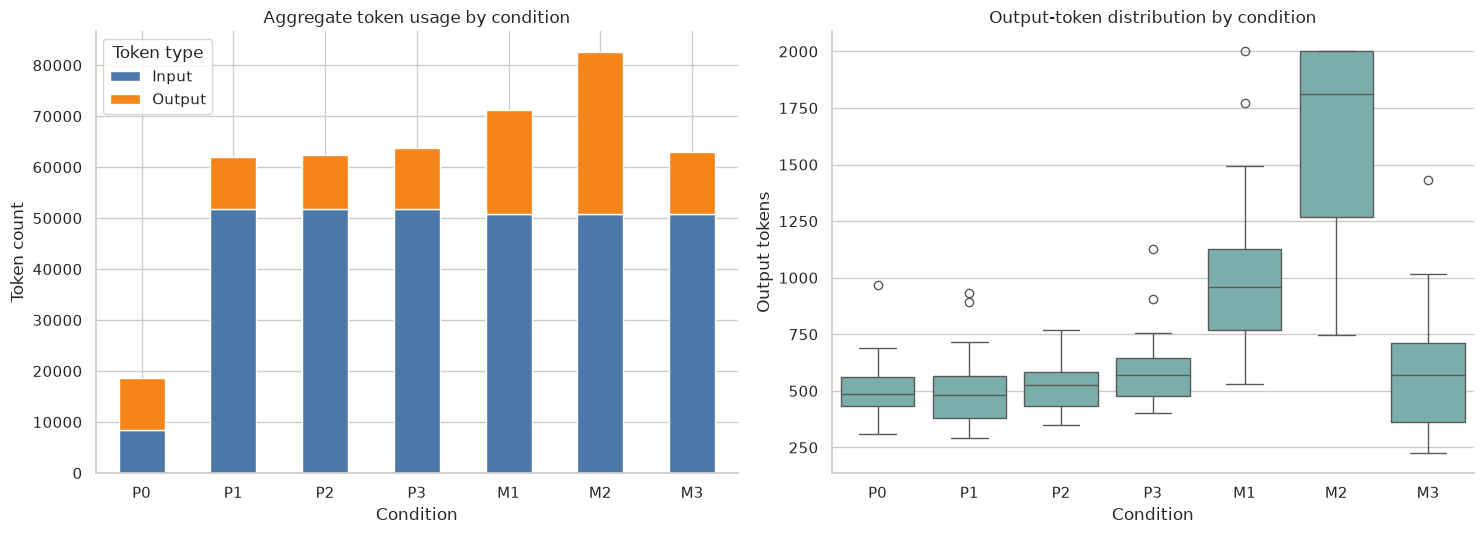

In [8]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
)

token_plot_data = (
    condition_summary
    .set_index("condition_id")[
        [
            "input_tokens",
            "output_tokens",
        ]
    ]
)

token_plot_data.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[
        "#4C78A8",
        "#F58518",
    ],
)

axes[0].set_title(
    "Aggregate token usage by condition"
)
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Token count")
axes[0].tick_params(
    axis="x",
    rotation=0,
)
axes[0].legend(
    title="Token type",
    labels=[
        "Input",
        "Output",
    ],
)

sns.boxplot(
    data=responses,
    x="condition_id",
    y="output_token_count",
    order=EXPECTED_CONDITION_IDS,
    color="#72B7B2",
    ax=axes[1],
)

axes[1].set_title(
    "Output-token distribution by condition"
)
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Output tokens")

sns.despine()
figure.tight_layout()
plt.show()

### 6.1 Completion availability and visible answer length

Reported output tokens and visible answer length must be examined
separately for reasoning models. The completion-status chart makes
the nine M2 non-answers visible, while the character-length chart
measures only text that was actually returned to the user.

These charts remain operational diagnostics and do not measure
answer correctness.

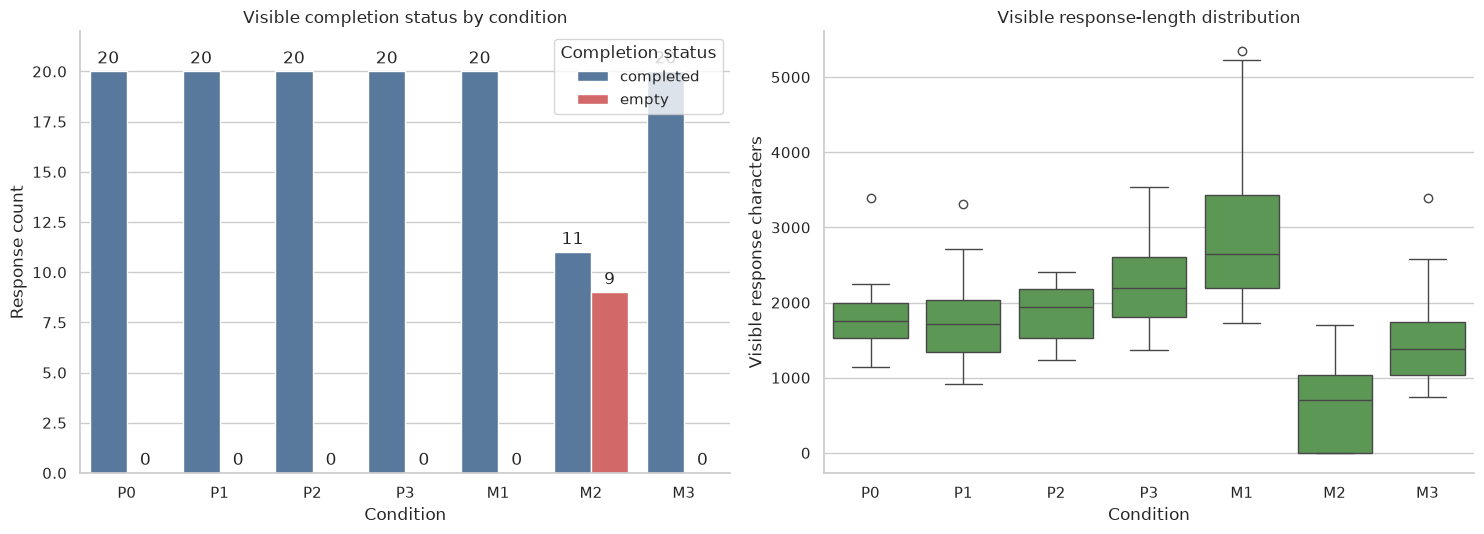

In [9]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
)

completion_plot_data = (
    completion_status_by_condition
    .rename_axis("condition_id")
    .reset_index()
    .melt(
        id_vars="condition_id",
        value_vars=[
            "completed",
            "empty",
        ],
        var_name="completion_status",
        value_name="response_count",
    )
)

sns.barplot(
    data=completion_plot_data,
    x="condition_id",
    y="response_count",
    hue="completion_status",
    order=EXPECTED_CONDITION_IDS,
    hue_order=[
        "completed",
        "empty",
    ],
    palette={
        "completed": "#4C78A8",
        "empty": "#E45756",
    },
    ax=axes[0],
)

axes[0].set_title(
    "Visible completion status by condition"
)
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Response count")
axes[0].legend(
    title="Completion status"
)
axes[0].set_ylim(
    0,
    22,
)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%d",
        padding=3,
    )

sns.boxplot(
    data=responses,
    x="condition_id",
    y="response_character_count",
    order=EXPECTED_CONDITION_IDS,
    color="#54A24B",
    ax=axes[1],
)

axes[1].set_title(
    "Visible response-length distribution"
)
axes[1].set_xlabel("Condition")
axes[1].set_ylabel(
    "Visible response characters"
)

sns.despine()
figure.tight_layout()
plt.show()

## 7. Audit boundary and next phase

This notebook establishes that the generation run is complete,
traceable, structurally valid, and within the authorised cost boundary.

It does not establish that any answer is correct. Correctness,
faithfulness, retrieval effects, baseline replication, and model
comparisons belong to the later evaluation workflow. That work will
begin only after the operational audit is frozen.

In [10]:
print("Generation integrity and operational audit:")
print("  Frozen fingerprints verified: True")
print("  Complete 20 by 7 matrix verified: True")
print("  Requested model identities verified: True")
print("  Returned model identities verified: True")
print("  Retry count verified as zero: True")
print("  Empty M2 responses preserved: 9")
print("  Selective regeneration performed: False")
print("  Cost boundary respected: True")
print("  Private response text displayed: False")
print("  Ground truth accessed: False")
print(
    "Generation integrity and operational "
    "audit: PASSED"
)

Generation integrity and operational audit:
  Frozen fingerprints verified: True
  Complete 20 by 7 matrix verified: True
  Requested model identities verified: True
  Returned model identities verified: True
  Retry count verified as zero: True
  Empty M2 responses preserved: 9
  Selective regeneration performed: False
  Cost boundary respected: True
  Private response text displayed: False
  Ground truth accessed: False
Generation integrity and operational audit: PASSED
